## Notebook 1 - Data Understanding and EDA

### 1. Problem Understanding

This notebook initiates our exploration into predicting the compatibility score between participants in a networking event. The core task is to develop a robust recommendation system that can accurately estimate a pairwise compatibility score, ranging from 0 to 1, for any two given participants. This type of prediction is crucial for facilitating meaningful connections and optimizing networking outcomes.

### 2. Dataset Overview

We are provided with three primary datasets:

*   **`train.xlsx`**: Contains participant profiles for the training set, including various demographic, professional, and interest-based attributes.
*   **`test.xlsx`**: Contains participant profiles for the test set, structured identically to the training set.
*   **`target.csv`**: Contains the ground truth pairwise compatibility scores, linking source and destination user IDs to their observed compatibility.

Both `train.xlsx` and `test.xlsx` share the following key features:
`Profile_ID`, `Age`, `Gender`, `Role`, `Seniority_Level`, `Company_Name`, `Company_Size_Employees`, `Industry`, `Location_City`, `Business_Interests`, `Business_Objectives`, `Constraints`.

### 3. Key Observations from EDA

Our initial exploratory data analysis reveals several important characteristics of the datasets:

*   **Missing Values**: Both `train.xlsx` and `test.xlsx` exhibit missing values, particularly in the `Seniority_Level` and `Company_Size_Employees` columns. These will require careful imputation or handling during feature engineering.
*   **Categorical Variety**: Columns like `Gender`, `Role`, `Seniority_Level`, `Industry`, and `Location_City` are categorical, with varying levels of cardinality. `Age` and `Company_Size_Employees` are numerical, with `Age` showing a somewhat normal distribution and `Company_Size_Employees` potentially skewed.
*   **Multi-value Text Columns**: `Business_Interests`, `Business_Objectives`, and `Constraints` are free-text fields that often contain multiple values, typically delimited by semicolons. This structure necessitates specialized text processing techniques (e.g., one-hot encoding, embedding) to convert them into usable features.
*   **Compatibility Score Distribution**: The `target.csv` file shows that the `compatibility_score` is predominantly clustered towards lower values, with a long tail extending to higher scores. This skewed distribution is common in recommendation systems and suggests that positive compatibility is a relatively rare event, which might influence model selection and evaluation metrics.

### 4. Why EDA Matters for this Recommendation Problem

For a recommendation problem such as predicting compatibility, thorough EDA is paramount. Understanding the nuances of each feature, including data types, distributions, missingness patterns, and the nature of categorical or multi-value text fields, directly informs the subsequent feature engineering and model development stages. Insights from EDA will guide decisions on:

*   **Feature Engineering**: How to effectively transform raw data into features that models can learn from, especially for text-based and categorical attributes.
*   **Missing Value Imputation**: Selecting appropriate strategies to handle missing `Seniority_Level` and `Company_Size_Employees` values to prevent data loss or bias.
*   **Model Selection**: The skewed distribution of `compatibility_score` might suggest the need for regression models robust to imbalanced targets or specialized loss functions.
*   **Bias Detection**: Identifying potential biases in the data that could lead to unfair or inaccurate recommendations.

### 5. Next Steps
In the next notebooks, we will:
- engineer pairwise structured + text features (Notebook 2)
- train supervised and latent-factor models for compatibility prediction (Notebook 3 / 3B)
- generate final predictions and submission file (Notebook 4)


In [ ]:
import pandas as pd
import numpy as np

train = pd.read_excel("train.xlsx")
test  = pd.read_excel("test.xlsx")
target = pd.read_csv("target.csv")

print("Train:", train.shape)
print("Test :", test.shape)
print("Target:", target.shape)

train.head()



Train: (600, 12)
Test : (400, 12)
Target: (65203, 3)


,Profile_ID,Age,Gender,Role,Seniority_Level,Company_Name,Company_Size_Employees,Industry,Location_City,Business_Interests,Business_Objectives,Constraints
0,5001,30,Non-binary,Investment Analyst,Senior,Bain,37.0,SaaS,Sydney,Product Management;Venture Capital,Looking for internship opportunities;Exploring...,Not evaluating service-based businesses
1,5002,28,Male,Marketing Manager,Executive,Zoho,171.0,Supply Chain,New York,Startup Ecosystem;Sales;SaaS;Open Source,Learning about industry trends;Looking for int...,Prefer B2C or high-growth startups
2,5003,57,Non-binary,Consultant,Senior,Shopee,71076.0,EdTech,Dubai,Startup Ecosystem;SaaS,Building professional visibility;Mentorship an...,Looking for short-term or project-based engage...
3,5004,52,Male,Marketing Manager,Senior,Microsoft,143.0,AI,San Francisco,AI;Startup Ecosystem,Learning about industry trends,Interested in growth or performance marketing ...
4,5005,41,Non-binary,Founder,NaN,Razorpay,37.0,Climate Tech,Berlin,SaaS,Networking with industry peers,Prefer discussions with decision-makers only;L...


In [ ]:
print("Train missing values:\n", train.isna().sum())
print("\nTest missing values:\n", test.isna().sum())

print("\nCompatibility score stats:")
print(target["compatibility_score"].describe())



Train missing values:
 Profile_ID                  0
Age                         0
Gender                      0
Role                        0
Seniority_Level           124
Company_Name                0
Company_Size_Employees     31
Industry                    0
Location_City               0
Business_Interests          0
Business_Objectives         0
Constraints                 0
dtype: int64

Test missing values:
 Profile_ID                 0
Age                        0
Gender                     0
Role                       0
Seniority_Level           82
Company_Name               0
Company_Size_Employees    31
Industry                   0
Location_City              0
Business_Interests         0
Business_Objectives        0
Constraints                0
dtype: int64

Compatibility score stats:
count    65202.000000
mean         0.096051
std          0.080271
min          0.000000
25%          0.055600
50%          0.076900
75%          0.142900
max          0.666700
Name: compatibil

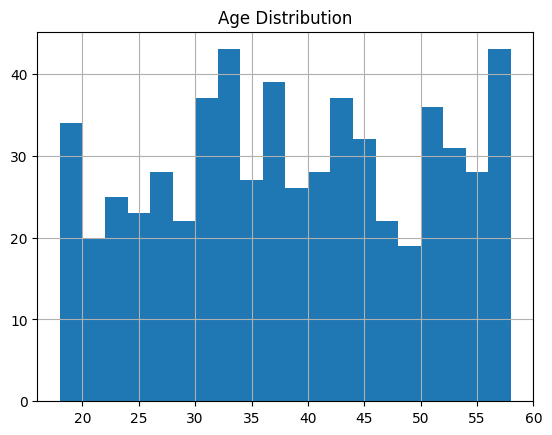

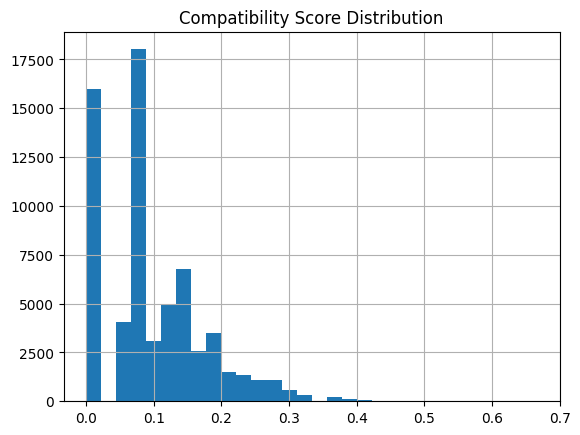

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
train["Age"].hist(bins=20)
plt.title("Age Distribution")
plt.show()

plt.figure()
target["compatibility_score"].hist(bins=30)
plt.title("Compatibility Score Distribution")
plt.show()
